# Model Comparisons and Final Model Selection

Now, to load in all of the histories of the models so I can compare the performances using validation vs training and ROC-AUC graphs.

In [1]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
import pickle
from tensorflow.keras import layers
from tensorflow.keras.models import load_model

2025-07-30 12:23:25.257787: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 12:23:25.267496: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 12:23:25.355826: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 12:23:25.448438: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753896205.543581   22381 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753896205.56

In [2]:
# Baseline MobileNetV2
with open('history_baseline.pkl', 'rb') as file:
    baseline_history = pickle.load(file)

# Augmented MobileNetV2
with open('history_mobilenet.pkl', 'rb') as file:
    mobile_history = pickle.load(file)
    
# Augmented EfficientNetB0
with open('history_efficientnet.pkl', 'rb') as file:
    efficient_history = pickle.load(file)
    
# Augmented DenseNet121
with open('history_densenet.pkl', 'rb') as file:
    dense_history = pickle.load(file)

In [3]:
# Load in the previous models
from keras.saving import register_keras_serializable

@register_keras_serializable(package="Custom")
def grayscale_to_rgb(x):
    return tf.image.grayscale_to_rgb(x)

baseline = load_model("baseline.keras")
mobile = load_model("mobilenet.keras")
efficient = load_model("efficientnet.keras")
dense = load_model("densenet.keras")

2025-07-30 12:23:31.819035: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
image_size = (224, 224)
batch_size = 10
seed = 42

valid_augmentation = keras.Sequential([
    layers.Rescaling(1./255),
])

valid_ds = tf.keras.utils.image_dataset_from_directory(
    "valid",
    batch_size=batch_size,
    image_size=image_size,
    color_mode="grayscale",  
    shuffle=False,            
    seed=seed
)

valid_ds = valid_ds.map(lambda x, y: (valid_augmentation(x), y))

Found 675 files belonging to 2 classes.


In [5]:
# Create training vs validation recall and loss graphs
def compare_graphs(history_dict, model_name):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Recall graph
    ax[0].plot(history_dict["recall"], label="Training Recall")
    ax[0].plot(history_dict["val_recall"], label="Validation Recall")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Recall")
    ax[0].set_title(f"{model_name} Recall")
    ax[0].legend()

    # Loss graph
    ax[1].plot(history_dict["loss"], label="Training Loss")
    ax[1].plot(history_dict["val_loss"], label="Validation Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].set_title(f"{model_name} Loss")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

The training and validation recalls bounced around for almost all of the models. However, the loss values in both training and validation continued to drop over the epochs relatively smoothly. EfficientNetB0 was extremely unstable and had a suspiciously perfect validation recall. For the final test, I'll be choosing MobileNetV2. It wasn't stopped early by EarlyStopping, has a slightly higher AUC score, and had a more stable loss compared to DenseNet121.

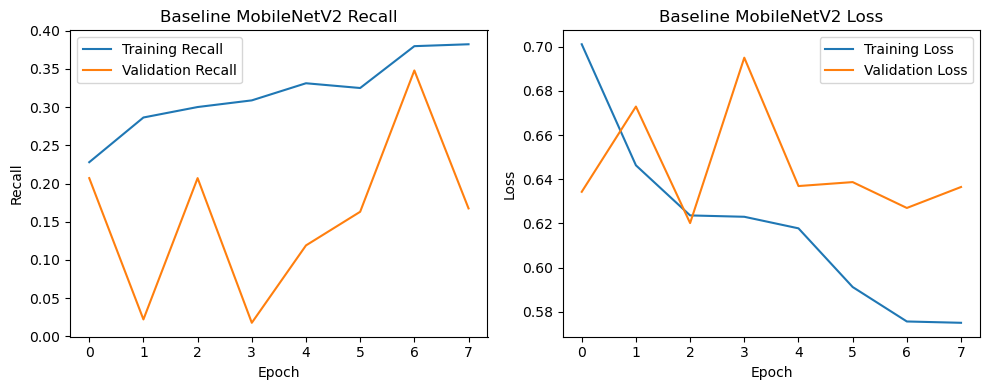

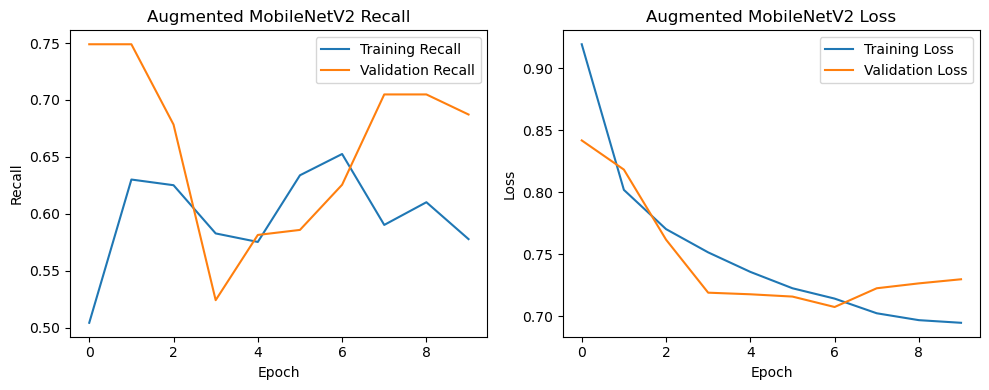

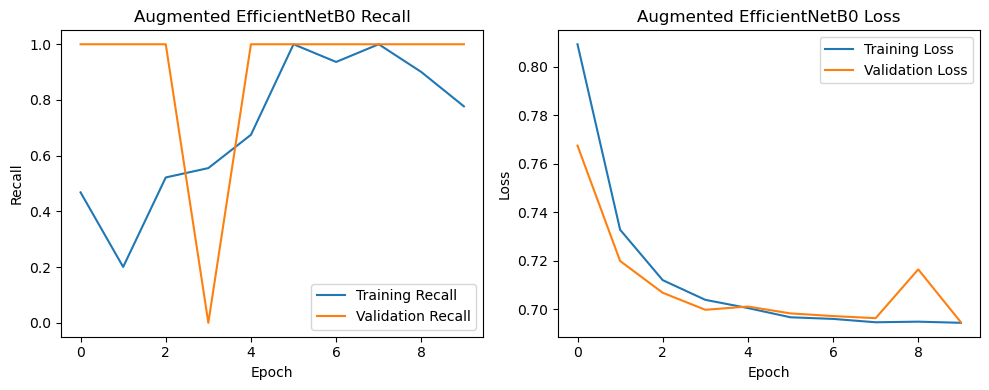

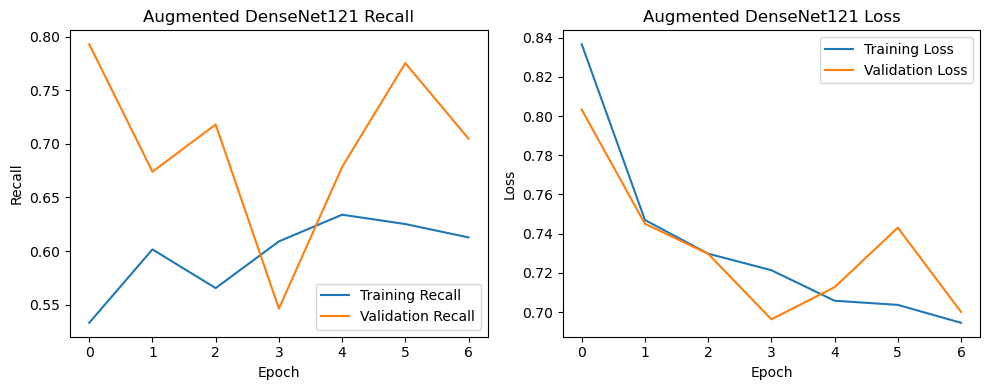

In [6]:
models_dict = {"Baseline MobileNetV2": baseline_history, 
               "Augmented MobileNetV2": mobile_history,
              "Augmented EfficientNetB0": efficient_history,
              "Augmented DenseNet121": dense_history}

for name, history in models_dict.items():
    compare_graphs(history, name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

2025-07-30 12:23:58.285162: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

2025-07-30 12:24:24.986453: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

2025-07-30 12:27:43.739666: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


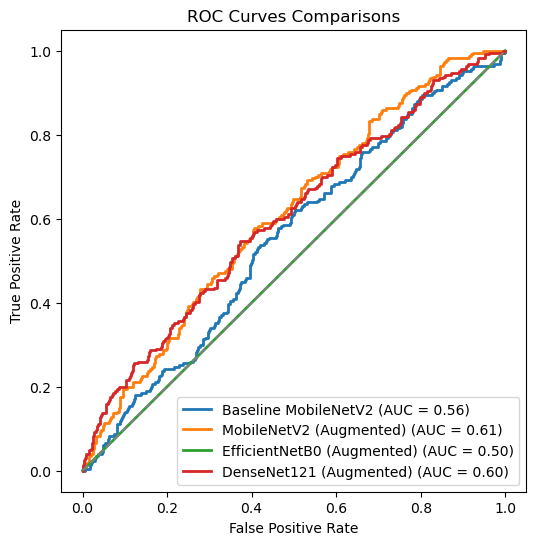

In [7]:
# Compare all the ROC curves and AUC scores on a single graph 
models = [baseline, mobile, efficient, dense]  
model_names = ["Baseline MobileNetV2", "MobileNetV2 (Augmented)", "EfficientNetB0 (Augmented)", "DenseNet121 (Augmented)"]

plt.figure(figsize=(6, 6))

for model, model_name in zip(models, model_names):
    y_true = []
    y_pred_probs = []

    for images, labels in valid_ds:
        
        # Convert from grayscale to RGB when charting the baseline model since its in RGB
        expected_channels = model.input_shape[-1]
        if expected_channels == 3:
            images = tf.image.grayscale_to_rgb(images)

        y_true.extend(labels.numpy())
        y_pred_probs.extend(model.predict(images).flatten())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)

    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparisons")
plt.legend()
plt.show()